In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
jeep_df = pd.read_csv("export_jeep_pool.csv")
jeep_df

,id,max_passengers,state,distance,speed,passenger_served,current_passengers,arrive_times,embark_times
0,0,20,1,1,0.0025,460,NaN,17396|25478|28279|31080|33288|34969|36650|3833...,16556|22678|25479|28280|31081|33289|34970|3665...
1,1,20,1,1,0.0025,453,4444|4446|4447|4448|4450|4451|4452|4453|4455|4...,12289|25496|28297|31098|33299|34980|36661|3834...,11449|22696|25497|28298|31099|33300|34981|3666...
2,2,20,1,1,0.0025,460,NaN,24537|27338|30139|32724|34405|36086|37767|3944...,21737|24538|27339|30140|32725|34406|36087|3776...
3,3,20,1,1,0.0025,440,NaN,22606|25647|28448|31249|33390|35071|36752|3843...,21062|22847|25648|28449|31250|33391|35072|3675...
4,4,20,0,0,0.0025,453,4431|4432|4437|4440|4445|4449|4454|4457|4458|4...,24792|27593|30394|32877|34558|36239|37920|3960...,21992|24793|27594|30395|32878|34559|36240|3792...
5,5,20,1,1,0.0025,440,NaN,24646|27447|30248|32789|34470|36151|37832|3951...,21846|24647|27448|30249|32790|34471|36152|3783...
6,6,20,0,0,0.0025,440,NaN,25019|27820|30621|33013|34694|36375|38056|3973...,22219|25020|27821|30622|33014|34695|36376|3805...
7,7,20,1,1,0.0025,440,NaN,24951|27752|30553|32972|34653|36334|38015|3969...,22151|24952|27753|30554|32973|34654|36335|3801...
8,8,20,0,0,0.0025,440,NaN,25238|28039|30840|33144|34825|36506|38187|3986...,22438|25239|28040|30841|33145|34826|36507|3818...
9,9,20,1,1,0.0025,440,NaN,25167|27968|30769|33102|34783|36464|38145|3982...,22367|25168|27969|30770|33103|34784|36465|3814...


In [3]:
jeep_df["arrive_times"] = jeep_df["arrive_times"].str.split('|').apply(lambda lst: list(map(int, lst)))

jeep_df["arrive_times"]

0    [17396, 25478, 28279, 31080, 33288, 34969, 366...
1    [12289, 25496, 28297, 31098, 33299, 34980, 366...
2    [24537, 27338, 30139, 32724, 34405, 36086, 377...
3    [22606, 25647, 28448, 31249, 33390, 35071, 367...
4    [24792, 27593, 30394, 32877, 34558, 36239, 379...
5    [24646, 27447, 30248, 32789, 34470, 36151, 378...
6    [25019, 27820, 30621, 33013, 34694, 36375, 380...
7    [24951, 27752, 30553, 32972, 34653, 36334, 380...
8    [25238, 28039, 30840, 33144, 34825, 36506, 381...
9    [25167, 27968, 30769, 33102, 34783, 36464, 381...
Name: arrive_times, dtype: object

In [4]:
jeep_df["embark_times"] = jeep_df["embark_times"].str.split('|').apply(lambda lst: list(map(int, lst)))

jeep_df["embark_times"]

0    [16556, 22678, 25479, 28280, 31081, 33289, 349...
1    [11449, 22696, 25497, 28298, 31099, 33300, 349...
2    [21737, 24538, 27339, 30140, 32725, 34406, 360...
3    [21062, 22847, 25648, 28449, 31250, 33391, 350...
4    [21992, 24793, 27594, 30395, 32878, 34559, 362...
5    [21846, 24647, 27448, 30249, 32790, 34471, 361...
6    [22219, 25020, 27821, 30622, 33014, 34695, 363...
7    [22151, 24952, 27753, 30554, 32973, 34654, 363...
8    [22438, 25239, 28040, 30841, 33145, 34826, 365...
9    [22367, 25168, 27969, 30770, 33103, 34784, 364...
Name: embark_times, dtype: object

In [5]:
jeep_df["queue_start_times"] = jeep_df["arrive_times"].apply(
    lambda times: [0] + times[:-1]
)



In [6]:
jeep_df["queue_wait_times"] = jeep_df.apply(
    lambda row: [eb - qs  for qs, eb in zip(row["queue_start_times"], row["embark_times"])],
    axis=1
)

In [7]:
jeep_df[["embark_times", "arrive_times", "queue_start_times", "queue_wait_times"]].head()


,embark_times,arrive_times,queue_start_times,queue_wait_times
0,"[16556, 22678, 25479, 28280, 31081, 33289, 349...","[17396, 25478, 28279, 31080, 33288, 34969, 366...","[0, 17396, 25478, 28279, 31080, 33288, 34969, ...","[16556, 5282, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 64..."
1,"[11449, 22696, 25497, 28298, 31099, 33300, 349...","[12289, 25496, 28297, 31098, 33299, 34980, 366...","[0, 12289, 25496, 28297, 31098, 33299, 34980, ...","[11449, 10407, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 8..."
2,"[21737, 24538, 27339, 30140, 32725, 34406, 360...","[24537, 27338, 30139, 32724, 34405, 36086, 377...","[0, 24537, 27338, 30139, 32724, 34405, 36086, ...","[21737, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 7973,..."
3,"[21062, 22847, 25648, 28449, 31250, 33391, 350...","[22606, 25647, 28448, 31249, 33390, 35071, 367...","[0, 22606, 25647, 28448, 31249, 33390, 35071, ...","[21062, 241, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 110..."
4,"[21992, 24793, 27594, 30395, 32878, 34559, 362...","[24792, 27593, 30394, 32877, 34558, 36239, 379...","[0, 24792, 27593, 30394, 32877, 34558, 36239, ...","[21992, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1212, 84..."


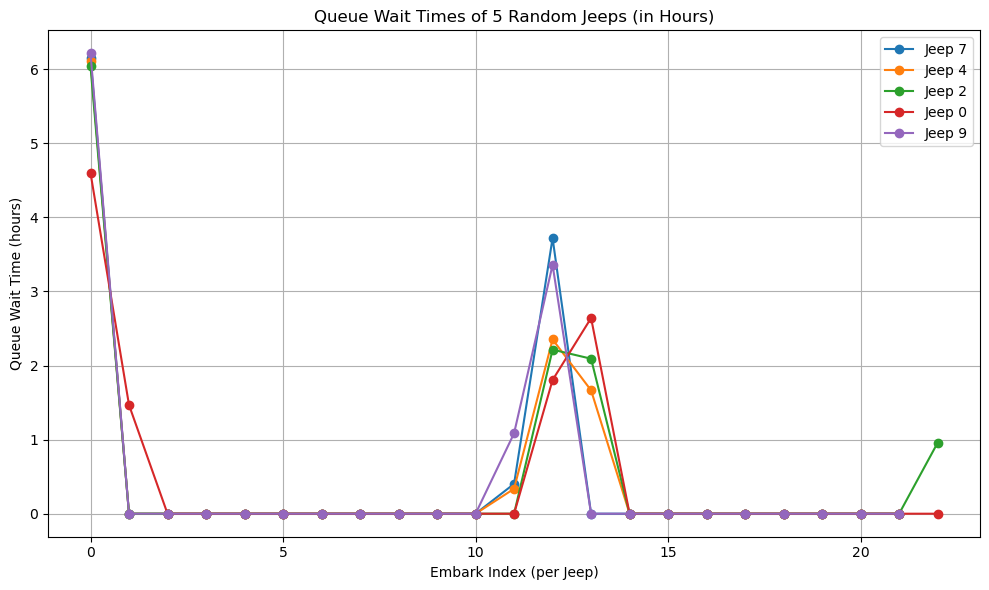

In [8]:
import random

# Randomly select 5 jeep indices
random_indices = random.sample(range(len(jeep_df)), 5)

# Plot each selected jeep's queue wait times (converted to hours)
plt.figure(figsize=(10, 6))
for idx in random_indices:
    wait_times_sec = jeep_df.loc[idx, "queue_wait_times"]
    wait_times_hr = [t / 3600 for t in wait_times_sec]  # Convert to hours
    plt.plot(range(len(wait_times_hr)), wait_times_hr, marker='o', label=f"Jeep {idx}")

plt.xlabel("Embark Index (per Jeep)")
plt.ylabel("Queue Wait Time (hours)")
plt.title("Queue Wait Times of 5 Random Jeeps (in Hours)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
jeep_df["embark_hours"] = jeep_df["embark_times"].apply(
    lambda times: [round(int(t) / 3600, 2) for t in times]
)

jeep_df["embark_hours"]

0    [4.6, 6.3, 7.08, 7.86, 8.63, 9.25, 9.71, 10.18...
1    [3.18, 6.3, 7.08, 7.86, 8.64, 9.25, 9.72, 10.1...
2    [6.04, 6.82, 7.59, 8.37, 9.09, 9.56, 10.02, 10...
3    [5.85, 6.35, 7.12, 7.9, 8.68, 9.28, 9.74, 10.2...
4    [6.11, 6.89, 7.67, 8.44, 9.13, 9.6, 10.07, 10....
5    [6.07, 6.85, 7.62, 8.4, 9.11, 9.58, 10.04, 10....
6    [6.17, 6.95, 7.73, 8.51, 9.17, 9.64, 10.1, 10....
7    [6.15, 6.93, 7.71, 8.49, 9.16, 9.63, 10.09, 10...
8    [6.23, 7.01, 7.79, 8.57, 9.21, 9.67, 10.14, 10...
9    [6.21, 6.99, 7.77, 8.55, 9.2, 9.66, 10.13, 10....
Name: embark_hours, dtype: object

In [10]:
jeep_df["arrive_hours"] = jeep_df["arrive_times"].apply(
    lambda times: [round(int(t) / 3600, 2) for t in times]
)

jeep_df["arrive_hours"]

0    [4.83, 7.08, 7.86, 8.63, 9.25, 9.71, 10.18, 10...
1    [3.41, 7.08, 7.86, 8.64, 9.25, 9.72, 10.18, 10...
2    [6.82, 7.59, 8.37, 9.09, 9.56, 10.02, 10.49, 1...
3    [6.28, 7.12, 7.9, 8.68, 9.28, 9.74, 10.21, 10....
4    [6.89, 7.66, 8.44, 9.13, 9.6, 10.07, 10.53, 11...
5    [6.85, 7.62, 8.4, 9.11, 9.57, 10.04, 10.51, 10...
6    [6.95, 7.73, 8.51, 9.17, 9.64, 10.1, 10.57, 11...
7    [6.93, 7.71, 8.49, 9.16, 9.63, 10.09, 10.56, 1...
8    [7.01, 7.79, 8.57, 9.21, 9.67, 10.14, 10.61, 1...
9    [6.99, 7.77, 8.55, 9.2, 9.66, 10.13, 10.6, 11....
Name: arrive_hours, dtype: object

In [11]:
jeep_df["gross_profit"] = jeep_df["passenger_served"] * 13

jeep_df["gross_profit"]

0    5980
1    5889
2    5980
3    5720
4    5889
5    5720
6    5720
7    5720
8    5720
9    5720
Name: gross_profit, dtype: int64

In [12]:
route_distance = 5 #change if needed
gas_price = 60
liters_per_km = 0.181818
jeep_df["gas_expense"] = len(jeep_df["embark_times"]) * route_distance * liters_per_km * gas_price

In [13]:
jeep_df["gas_expense"]

0    545.454
1    545.454
2    545.454
3    545.454
4    545.454
5    545.454
6    545.454
7    545.454
8    545.454
9    545.454
Name: gas_expense, dtype: float64

In [14]:
jeep_df["net_profit"] = jeep_df["gross_profit"] - jeep_df["gas_expense"]

In [15]:
jeep_df

,id,max_passengers,state,distance,speed,passenger_served,current_passengers,arrive_times,embark_times,queue_start_times,queue_wait_times,embark_hours,arrive_hours,gross_profit,gas_expense,net_profit
0,0,20,1,1,0.0025,460,NaN,"[17396, 25478, 28279, 31080, 33288, 34969, 366...","[16556, 22678, 25479, 28280, 31081, 33289, 349...","[0, 17396, 25478, 28279, 31080, 33288, 34969, ...","[16556, 5282, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 64...","[4.6, 6.3, 7.08, 7.86, 8.63, 9.25, 9.71, 10.18...","[4.83, 7.08, 7.86, 8.63, 9.25, 9.71, 10.18, 10...",5980,545.454,5434.546
1,1,20,1,1,0.0025,453,4444|4446|4447|4448|4450|4451|4452|4453|4455|4...,"[12289, 25496, 28297, 31098, 33299, 34980, 366...","[11449, 22696, 25497, 28298, 31099, 33300, 349...","[0, 12289, 25496, 28297, 31098, 33299, 34980, ...","[11449, 10407, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 8...","[3.18, 6.3, 7.08, 7.86, 8.64, 9.25, 9.72, 10.1...","[3.41, 7.08, 7.86, 8.64, 9.25, 9.72, 10.18, 10...",5889,545.454,5343.546
2,2,20,1,1,0.0025,460,NaN,"[24537, 27338, 30139, 32724, 34405, 36086, 377...","[21737, 24538, 27339, 30140, 32725, 34406, 360...","[0, 24537, 27338, 30139, 32724, 34405, 36086, ...","[21737, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 7973,...","[6.04, 6.82, 7.59, 8.37, 9.09, 9.56, 10.02, 10...","[6.82, 7.59, 8.37, 9.09, 9.56, 10.02, 10.49, 1...",5980,545.454,5434.546
3,3,20,1,1,0.0025,440,NaN,"[22606, 25647, 28448, 31249, 33390, 35071, 367...","[21062, 22847, 25648, 28449, 31250, 33391, 350...","[0, 22606, 25647, 28448, 31249, 33390, 35071, ...","[21062, 241, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 110...","[5.85, 6.35, 7.12, 7.9, 8.68, 9.28, 9.74, 10.2...","[6.28, 7.12, 7.9, 8.68, 9.28, 9.74, 10.21, 10....",5720,545.454,5174.546
4,4,20,0,0,0.0025,453,4431|4432|4437|4440|4445|4449|4454|4457|4458|4...,"[24792, 27593, 30394, 32877, 34558, 36239, 379...","[21992, 24793, 27594, 30395, 32878, 34559, 362...","[0, 24792, 27593, 30394, 32877, 34558, 36239, ...","[21992, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1212, 84...","[6.11, 6.89, 7.67, 8.44, 9.13, 9.6, 10.07, 10....","[6.89, 7.66, 8.44, 9.13, 9.6, 10.07, 10.53, 11...",5889,545.454,5343.546
5,5,20,1,1,0.0025,440,NaN,"[24646, 27447, 30248, 32789, 34470, 36151, 378...","[21846, 24647, 27448, 30249, 32790, 34471, 361...","[0, 24646, 27447, 30248, 32789, 34470, 36151, ...","[21846, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 12723...","[6.07, 6.85, 7.62, 8.4, 9.11, 9.58, 10.04, 10....","[6.85, 7.62, 8.4, 9.11, 9.57, 10.04, 10.51, 10...",5720,545.454,5174.546
6,6,20,0,0,0.0025,440,NaN,"[25019, 27820, 30621, 33013, 34694, 36375, 380...","[22219, 25020, 27821, 30622, 33014, 34695, 363...","[0, 25019, 27820, 30621, 33013, 34694, 36375, ...","[22219, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3868, 75...","[6.17, 6.95, 7.73, 8.51, 9.17, 9.64, 10.1, 10....","[6.95, 7.73, 8.51, 9.17, 9.64, 10.1, 10.57, 11...",5720,545.454,5174.546
7,7,20,1,1,0.0025,440,NaN,"[24951, 27752, 30553, 32972, 34653, 36334, 380...","[22151, 24952, 27753, 30554, 32973, 34654, 363...","[0, 24951, 27752, 30553, 32972, 34653, 36334, ...","[22151, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1451, 13...","[6.15, 6.93, 7.71, 8.49, 9.16, 9.63, 10.09, 10...","[6.93, 7.71, 8.49, 9.16, 9.63, 10.09, 10.56, 1...",5720,545.454,5174.546
8,8,20,0,0,0.0025,440,NaN,"[25238, 28039, 30840, 33144, 34825, 36506, 381...","[22438, 25239, 28040, 30841, 33145, 34826, 365...","[0, 25238, 28039, 30840, 33144, 34825, 36506, ...","[22438, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 5438, 82...","[6.23, 7.01, 7.79, 8.57, 9.21, 9.67, 10.14, 10...","[7.01, 7.79, 8.57, 9.21, 9.67, 10.14, 10.61, 1...",5720,545.454,5174.546
9,9,20,1,1,0.0025,440,NaN,"[25167, 27968, 30769, 33102, 34783, 36464, 381...","[22367, 25168, 27969, 30770, 33103, 34784, 364...","[0, 25167, 27968, 30769, 33102, 34783, 36464, ...","[22367, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3908, 12...","[6.21, 6.99, 7.77, 8.55, 9.2, 9.66, 10.13, 10....","[6.99, 7.77, 8.55, 9.2, 9.66, 10.13, 10.6, 11....",5720,545.454,5174.546


In [16]:
passenger_df = pd.read_csv("export_passenger_pool.csv")

passenger_df[["terminal_arrival_time","board_time","leave_time","destination_arrival_time"]] = passenger_df[["terminal_arrival_time","board_time","leave_time","destination_arrival_time"]].apply(lambda times: [round(int(t) / 3600, 2) for t in times] )

passenger_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal
0,0,0.25,0.25,3.18,3.41,1,1
1,1,0.34,0.34,3.18,3.41,1,1
2,2,0.52,0.52,3.18,3.41,1,1
3,3,0.52,0.52,3.18,3.41,1,1
4,4,0.69,0.69,3.18,3.41,1,1
...,...,...,...,...,...,...,...
4461,4461,23.75,23.75,0.00,0.00,4,0
4462,4462,23.75,23.75,0.00,0.00,1,1
4463,4463,23.77,23.77,0.00,0.00,4,0
4464,4464,23.90,23.90,0.00,0.00,1,1


In [17]:
passenger_df["turn_around_time"] = passenger_df["destination_arrival_time"] - passenger_df["terminal_arrival_time"]

passenger_df = passenger_df[passenger_df["turn_around_time"] > 0]

passenger_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal,turn_around_time
0,0,0.25,0.25,3.18,3.41,1,1,3.16
1,1,0.34,0.34,3.18,3.41,1,1,3.07
2,2,0.52,0.52,3.18,3.41,1,1,2.89
3,3,0.52,0.52,3.18,3.41,1,1,2.89
4,4,0.69,0.69,3.18,3.41,1,1,2.72
...,...,...,...,...,...,...,...,...
4438,4438,22.74,22.74,23.18,23.44,8,1,0.70
4439,4439,22.88,22.88,23.18,23.44,8,1,0.56
4441,4441,22.98,22.98,23.18,23.44,8,1,0.46
4442,4442,23.06,23.06,23.18,23.44,8,1,0.38


In [18]:
terminal_0_df = passenger_df[passenger_df["terminal"] == 0]
terminal_1_df = passenger_df[passenger_df["terminal"] == 1]


In [19]:
terminal_0_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal,turn_around_time
8,8,1.17,1.17,4.60,4.83,0,0,3.66
9,9,1.18,1.18,4.60,4.83,0,0,3.65
13,13,1.49,1.49,4.60,4.83,0,0,3.34
17,17,1.77,1.77,4.60,4.83,0,0,3.06
19,19,1.93,1.93,4.60,4.83,0,0,2.90
...,...,...,...,...,...,...,...,...
4416,4416,21.87,21.87,22.33,22.59,2,0,0.72
4417,4417,21.89,21.89,22.33,22.59,2,0,0.70
4420,4420,22.02,22.02,22.33,22.59,2,0,0.57
4422,4422,22.05,22.05,22.33,22.59,2,0,0.54


In [20]:
terminal_1_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal,turn_around_time
0,0,0.25,0.25,3.18,3.41,1,1,3.16
1,1,0.34,0.34,3.18,3.41,1,1,3.07
2,2,0.52,0.52,3.18,3.41,1,1,2.89
3,3,0.52,0.52,3.18,3.41,1,1,2.89
4,4,0.69,0.69,3.18,3.41,1,1,2.72
...,...,...,...,...,...,...,...,...
4438,4438,22.74,22.74,23.18,23.44,8,1,0.70
4439,4439,22.88,22.88,23.18,23.44,8,1,0.56
4441,4441,22.98,22.98,23.18,23.44,8,1,0.46
4442,4442,23.06,23.06,23.18,23.44,8,1,0.38


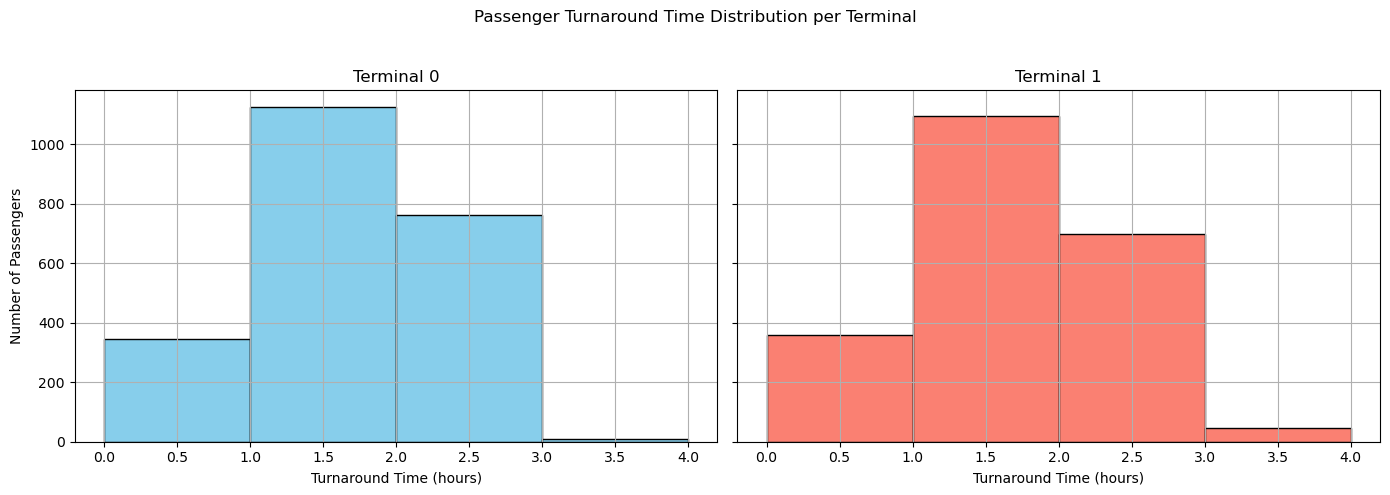

In [21]:

# Define bins (hourly intervals)
max_turnaround = max(terminal_0_df["turn_around_time"].max(), terminal_1_df["turn_around_time"].max())
bins = range(0, int(max_turnaround) + 2)

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Terminal 0 histogram
axs[0].hist(terminal_0_df["turn_around_time"], bins=bins, color='skyblue', edgecolor='black')
axs[0].set_title("Terminal 0")
axs[0].set_xlabel("Turnaround Time (hours)")
axs[0].set_ylabel("Number of Passengers")
axs[0].grid(True)

# Terminal 1 histogram
axs[1].hist(terminal_1_df["turn_around_time"], bins=bins, color='salmon', edgecolor='black')
axs[1].set_title("Terminal 1")
axs[1].set_xlabel("Turnaround Time (hours)")
axs[1].grid(True)

plt.suptitle("Passenger Turnaround Time Distribution per Terminal")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

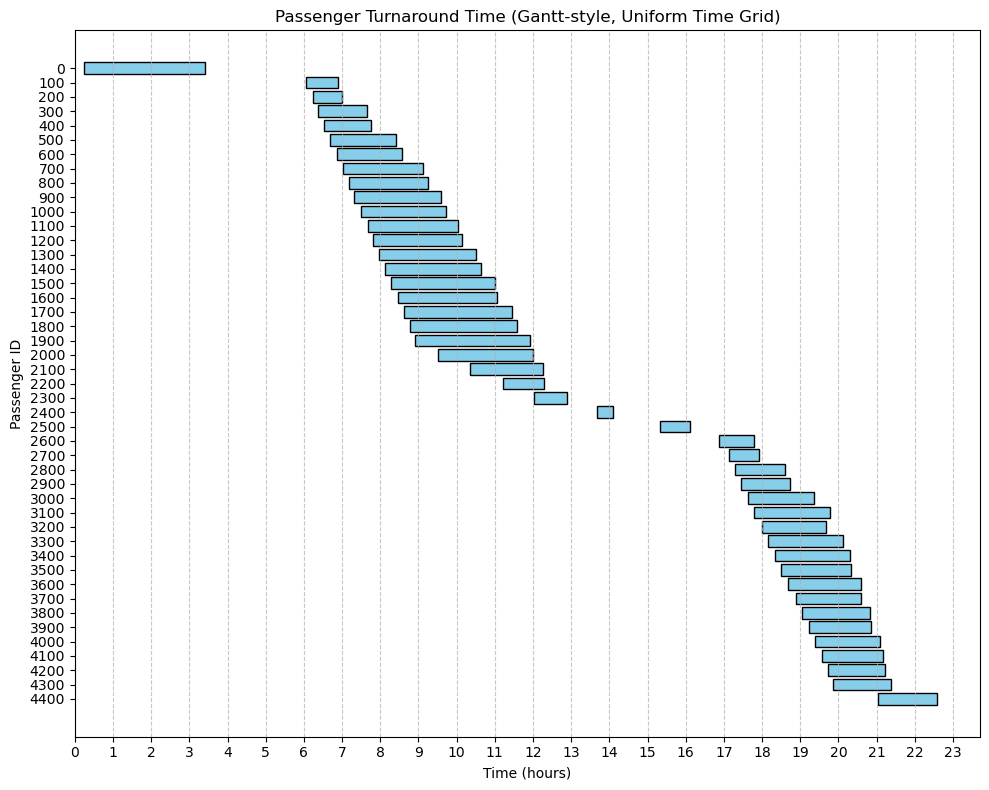

In [22]:

sample_df = passenger_df.iloc[::100].copy()

# Sample by index increments (e.g., every 100th row)
sample_df = passenger_df.iloc[::100].copy()

# Prepare data
starts = sample_df["terminal_arrival_time"]
durations = sample_df["turn_around_time"]
passenger_ids = sample_df["passenger_id"].astype(str)

# Set figure
plt.figure(figsize=(10, 8))
plt.barh(passenger_ids, durations, left=starts, color='skyblue', edgecolor='black')

# Set x-axis gridlines and ticks at every 1 hour
xmin = int(sample_df["terminal_arrival_time"].min())
xmax = int(sample_df["destination_arrival_time"].max()) + 1
plt.xticks(np.arange(xmin, xmax + 1, 1))  # every 1 hour
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

# Labels and layout
plt.xlabel("Time (hours)")
plt.ylabel("Passenger ID")
plt.title("Passenger Turnaround Time (Gantt-style, Uniform Time Grid)")
plt.tight_layout()
plt.gca().invert_yaxis()

plt.show()

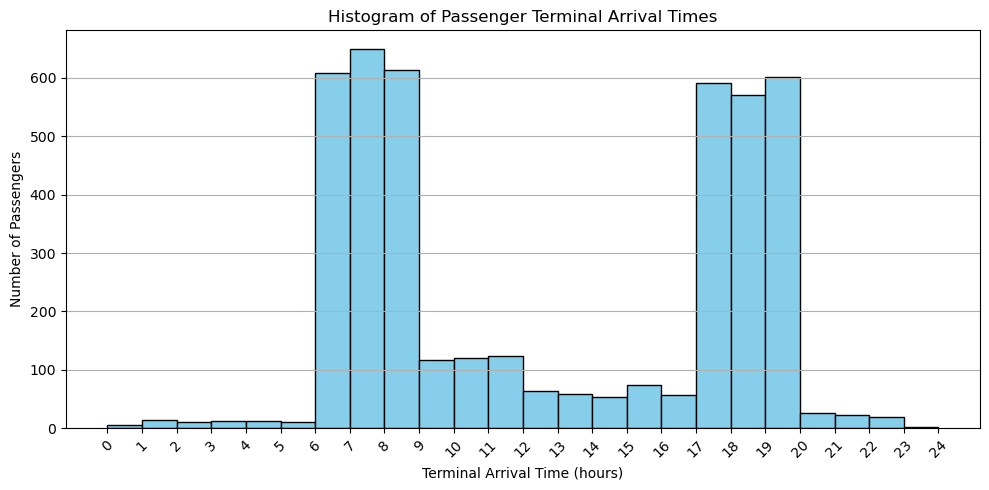

In [23]:
# Define bins: from min to max time, 1-hour step
min_time = int(passenger_df["terminal_arrival_time"].min())
max_time = int(passenger_df["terminal_arrival_time"].max()) + 1
bins = np.arange(min_time, max_time + 1, 1)  # 1-hour bins

# Plot
plt.figure(figsize=(10, 5))
plt.hist(passenger_df["terminal_arrival_time"], bins=bins, color='skyblue', edgecolor='black')

# Labels and styling
plt.xlabel("Terminal Arrival Time (hours)")
plt.ylabel("Number of Passengers")
plt.title("Histogram of Passenger Terminal Arrival Times")
plt.grid(True, axis='y')
plt.xticks(bins, rotation=45)
plt.tight_layout()
plt.show()

In [24]:
average_net_profit = jeep_df['net_profit'].mean()
print(average_net_profit)

5260.3460000000005


In [25]:
average_gross_profit = jeep_df['gross_profit'].mean()
print(average_gross_profit)

5805.8
